# Import data

In [1]:
# import zipfile

# zip_file = zipfile.ZipFile("OriginalDataset.zip",'r')
# zip_file.extractall()

In [2]:
import cv2
import matplotlib.pyplot as plt

def imshow(filename):
  image = cv2.imread(filename)

  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()
  print(image.shape)

In [3]:
path = 'D:/programing/Final Project/Alzheimer/dataset/Dataset/'

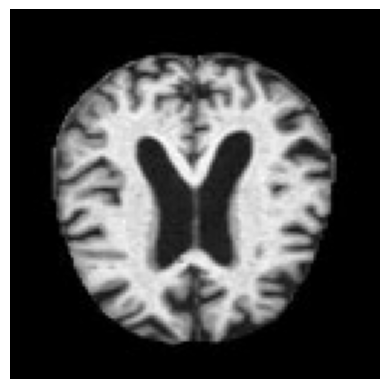

(128, 128, 3)


In [4]:
imshow(path+'Mild_Demented/mild.jpg')

# Image Preprocessing

In [5]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image
import numpy as np
import random
random.seed(0)
torch.manual_seed(0)
np.random.seed(0)
torchvision.disable_beta_transforms_warning()

## CustomDataset to import dataset

In [6]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.images = self._get_images()
        self.class_count = self._get_class_count()
        self.images_splited_each_class = self._split_img_each_class()

    def _get_images(self):
        images = []
        for cls in self.classes:
            class_path = os.path.join(self.root_dir, cls)
            class_idx = self.class_to_idx[cls]
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                images.append((img_path, class_idx))
        return images
    
    def _get_class_count(self):
        class_count = {}
        for cls_name in self.class_to_idx.values():
            class_count[cls_name] = 0
        for key,value in self.images:
           class_count[value] += 1 
        return class_count
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)
        return img, label
    
    def _get_labels(self):
        return [i[1] for i in self.images]
    
    def _split_img_each_class(self):
        data_class_split = {}
        for i in self.class_to_idx.values():
            data_class_split[i] = []
        for i in self.class_to_idx.values():
            for j in range(len(self.images)):
                if self.images[j][-1] == i:
                    data_class_split[i].append(self.images[j])
        return data_class_split


In [7]:
sample_data = CustomDataset(root_dir='D:/programing/Final Project/Alzheimer/dataset/Dataset')

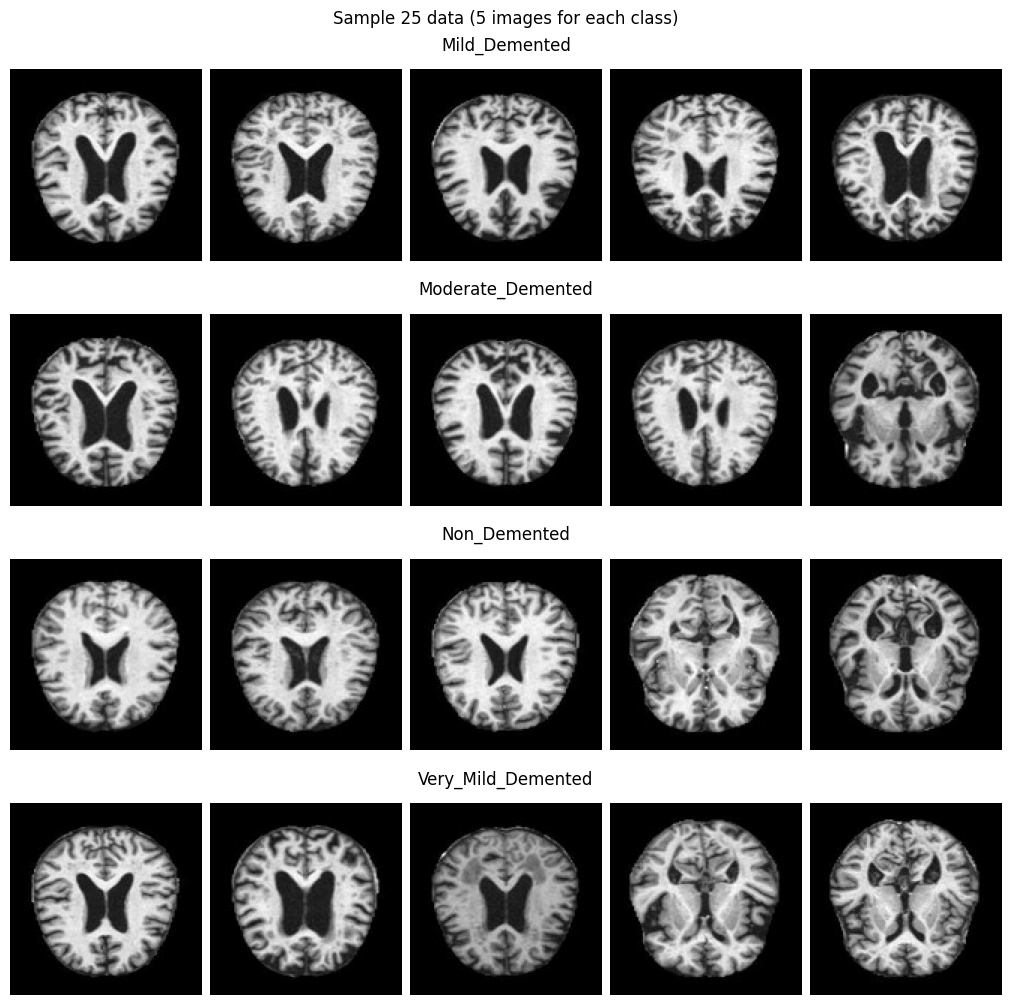

In [8]:
import matplotlib.image as mpimg
import copy

sample_data_dict = copy.deepcopy(sample_data.images_splited_each_class)

# create 4x1 subplots
fig, axs = plt.subplots(nrows=4, ncols=1, constrained_layout=True, figsize=(10, 10))
fig.suptitle('Sample 25 data (5 images for each class)')

# clear subplots
for ax in axs:
    ax.remove()

# add subfigure per subplot
gridspec = axs[0].get_subplotspec().get_gridspec()
subfigs = [fig.add_subfigure(gs) for gs in gridspec]

for row, subfig in enumerate(zip(subfigs,sample_data.classes)):
    subfig[0].suptitle(subfig[-1])

    # create 1x5 subplots per subfig
    axs = subfig[0].subplots(nrows=1, ncols=5)

    for class_label, images in sample_data_dict.items():
        for i in range(5):
            img = mpimg.imread(images[i][0])
            axs[i].imshow(img,cmap='gray')
            axs[i].axis('off')
        break
 
    del sample_data_dict[class_label]

plt.show()

## AddGaussianNoise

In [9]:
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=1.0, probability=0.5):
        self.std = std
        self.mean = mean
        self.probability = probability
        
    def __call__(self, tensor):
        if random.random() < self.probability:
            return tensor + (torch.randn(tensor.size()) * self.std) + self.mean
        else:
            return tensor
    
    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

## Contrast-limited Adaptive Histogram Equalization (CLAHE)

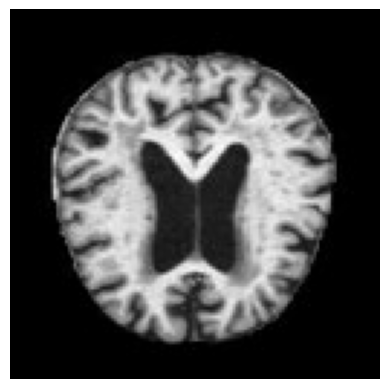

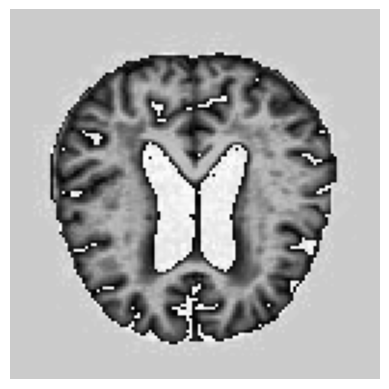

In [10]:
# Reading the image from the present directory
image = cv2.imread(path+'Mild_Demented/mild_2.jpg')
# Resizing the image for compatibility

# The initial processing of the image
# image = cv2.medianBlur(image, 3)
image_bw = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
 
# The declaration of CLAHE
# clipLimit -> Threshold for contrast limiting
clahe = cv2.createCLAHE(clipLimit=3,tileGridSize=(1,1))
final_img = clahe.apply(image_bw) + 200
 
# Showing the two images
plt.imshow(cv2.cvtColor(image_bw, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [11]:
import cv2

class AddCLAHE():
    def __init__(self, clipLimit=3, tileGridSize=(1, 1), threshold=200) -> None:
        self.clipLimit = clipLimit
        self.tileGridSize = tileGridSize
        self.threshold = threshold

    def __call__(self, tensor):
        tensor = tensor.numpy() * 255 
        tensor = tensor.astype('uint8')[0]

        clahe = cv2.createCLAHE(clipLimit=self.clipLimit, tileGridSize=self.tileGridSize)
        transformed_tensor = clahe.apply(tensor)
        transformed_tensor = torch.from_numpy(transformed_tensor).float() + self.threshold
        transformed_tensor = transformed_tensor / 255
        transformed_tensor = transformed_tensor.unsqueeze(0)

        return transformed_tensor

    def __repr__(self):
        return self.__class__.__name__ + '(clipLimit={}, tileGridSize={}, threshold={})'.format(
            self.clipLimit, self.tileGridSize, self.threshold
        )

## Split white and gray matter

In [12]:
class split_white_and_gray():
    def __init__(self,threshold=120) -> None:
        self.threshold = threshold

    def __call__(self,tensor):
        tensor = (tensor*255).to(torch.int64)

        # Apply thresholding
        gray_matter = torch.where(tensor >= self.threshold,tensor,0)
        gray_matter = (gray_matter/255).to(torch.float64)
        white_matter = torch.where(tensor < self.threshold,tensor,0)
        white_matter = (white_matter/255).to(torch.float64)
        tensor = (tensor/255).to(torch.float64)

        return torch.cat((gray_matter, white_matter,tensor), dim=0)

# Prepare Dataset 

## Data transforms

In [13]:
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    split_white_and_gray(120),
    #AddCLAHE(),
    #AddGaussianNoise(0,0.05), 
])

In [14]:
Dataset = CustomDataset(root_dir='D:/programing/Final Project/Alzheimer/dataset/Dataset', transform=transform)

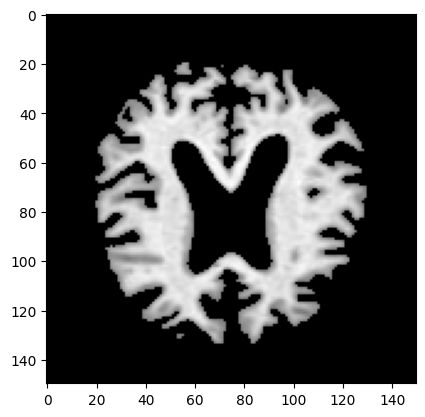

In [15]:
plt.imshow(transforms.ToPILImage()(Dataset[0][0][0]),cmap='gray')
plt.show()

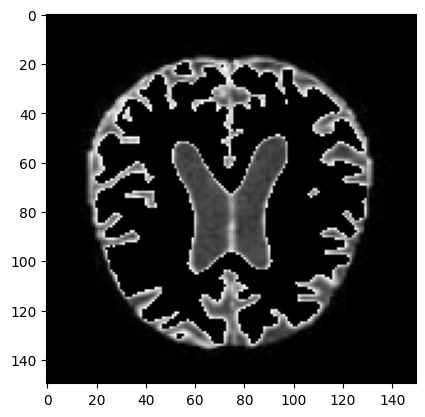

In [16]:
plt.imshow(transforms.ToPILImage()(Dataset[0][0][1]),cmap='gray')
plt.show()

## Split dataset 

In [17]:
from torch.utils.data import random_split

# Assuming you have a dataset named 'dataset' and it contains your data
dataset_size = len(Dataset)
train_size = int(0.7 * dataset_size)  # 70% for training
val_size = int(0.15 * dataset_size)  # 15% for validation
test_size = dataset_size - train_size - val_size  # Remaining 15% for testing

train_dataset, val_test_dataset = random_split(Dataset, [train_size, val_size + test_size])
val_dataset, test_dataset = random_split(val_test_dataset, [val_size, test_size])

## Over sampling method

In [18]:
def OverSample(Dataset):
    data = list(Dataset)
    class_count = {0:0, 1:0, 2:0, 3:0}
    for _, class_name in data:
        class_count[class_name] += 1

    # Calculate class weights for oversampling
    class_counts = list(class_count.values())
    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)

    # Assign weights to each sample based on its class
    
    weights = [class_weights[label] for _, label in data]

    # Create a WeightedRandomSampler to oversample minority classes
    sampler = WeightedRandomSampler(weights, 2000, replacement=True)

    return sampler

In [19]:
batch_size=64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=OverSample(train_dataset))
val_dataloader = DataLoader(val_dataset, batch_size=batch_size,)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size,)


In [20]:
class_counts = {label: 0 for label in range(len(Dataset.classes))}

# Iterate through the DataLoader
for _, labels in train_dataloader:
    for label in labels:
        class_counts[label.item()] += 1

# Print the counts
for label, count in class_counts.items():
    print(f"Class {label}: {count} items")

Class 0: 516 items
Class 1: 459 items
Class 2: 484 items
Class 3: 541 items


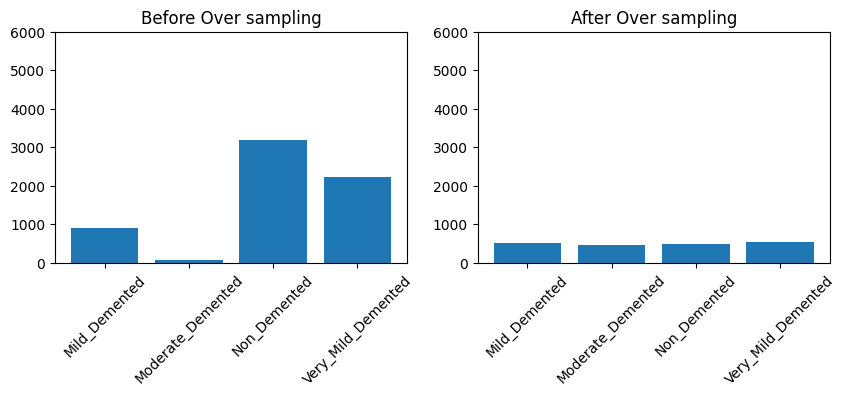

In [21]:
# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))  # Adjust the figsize as needed

# Add the first subplot
ax1.bar(Dataset.classes, Dataset.class_count.values())
ax1.set_xticks(range(len(Dataset.classes)))
ax1.set_xticklabels(Dataset.classes, rotation=45)
ax1.set_ylim(top=6000)
ax1.set_title("Before Over sampling")

# Add the second subplot
ax2.bar(Dataset.classes, class_counts.values())
ax2.set_xticks(range(len(Dataset.classes)))
ax2.set_xticklabels(Dataset.classes, rotation=45)
ax2.set_ylim(top=6000)
ax2.set_title("After Over sampling")

plt.show()


## visualization of each class

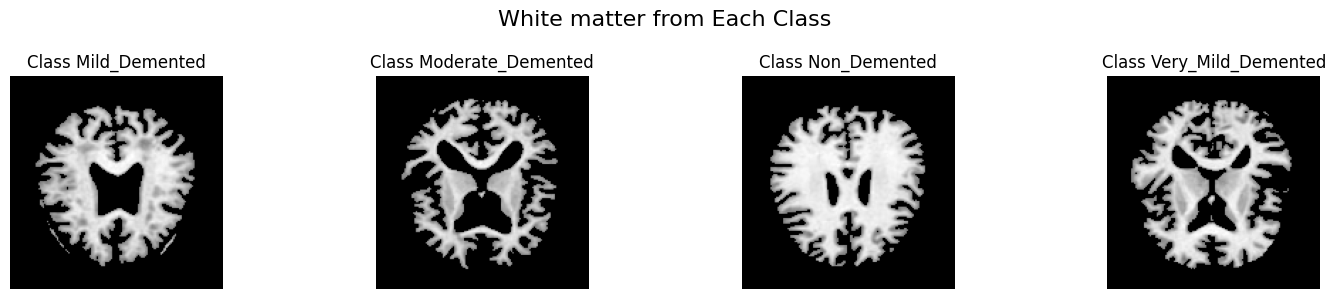

In [22]:
images, labels = next(iter(train_dataloader))

img_index = []
for label in labels.unique():
    img_index.append(list(labels).index(label))

image_each_classes = []
for idx in img_index:
    image_each_classes.append(images[idx])

# Plot one image from each class
fig, axs = plt.subplots(1, len(Dataset.classes), figsize=(15, 3))
fig.suptitle("White matter from Each Class", fontsize=16)

for class_num, i in enumerate(zip(Dataset.classes,image_each_classes)):
    axs[class_num].imshow(transforms.ToPILImage()(i[-1][0]),cmap='gray')
    axs[class_num].set_title(f"Class {i[0]}")
    axs[class_num].axis('off')

plt.tight_layout()
plt.show()

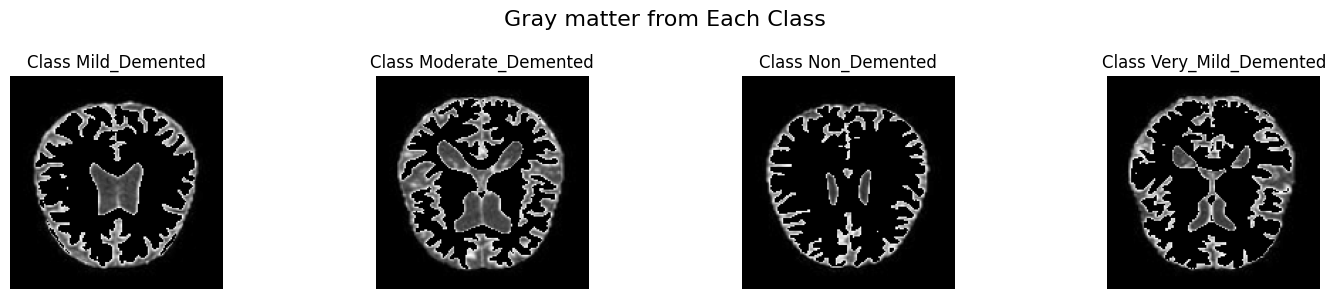

In [23]:
# Plot one image from each class
fig, axs = plt.subplots(1, len(Dataset.classes), figsize=(15, 3))
fig.suptitle("Gray matter from Each Class", fontsize=16)

for class_num, i in enumerate(zip(Dataset.classes,image_each_classes)):
    axs[class_num].imshow(transforms.ToPILImage()(i[-1][1]),cmap='gray')
    axs[class_num].set_title(f"Class {i[0]}")
    axs[class_num].axis('off')

plt.tight_layout()
plt.show()

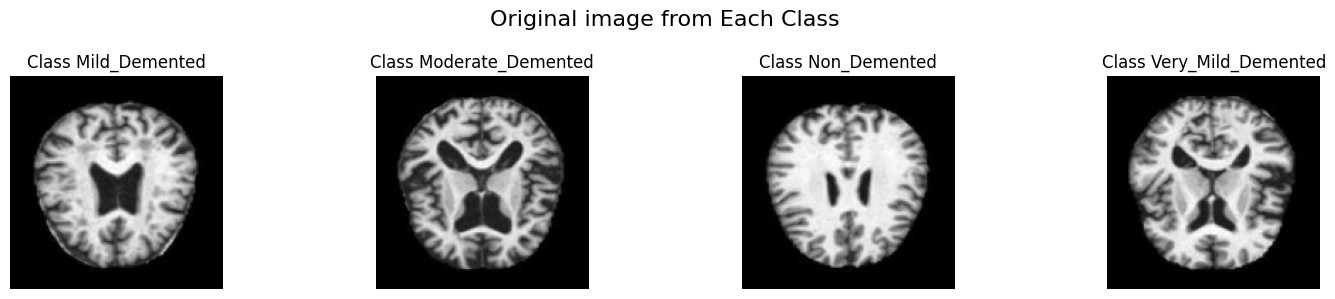

In [24]:
# Plot one image from each class
fig, axs = plt.subplots(1, len(Dataset.classes), figsize=(15, 3))
fig.suptitle("Original image from Each Class", fontsize=16)

for class_num, i in enumerate(zip(Dataset.classes,image_each_classes)):
    axs[class_num].imshow(transforms.ToPILImage()(i[-1][2]),cmap='gray')
    axs[class_num].set_title(f"Class {i[0]}")
    axs[class_num].axis('off')

plt.tight_layout()
plt.show()

# Backbone FeatureExtractor

class names : https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json,
https://github.com/anishathalye/imagenet-simple-labels/blob/master/imagenet-simple-labels.json

In [25]:
import requests

# Fetch the ImageNet class labels
LABELS_URL = 'https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json'
response = requests.get(LABELS_URL)
labels = response.json()

labels[:10]

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead shark',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich']

In [26]:
import torch.nn as nn
import torchvision.models as models
import collections
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# Load pre-trained ResNet-18 model
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove the last layer (classification head)
resnet18_removelast = nn.Sequential(*list(resnet18.children())[:-1])

# Add a new classification head for 4 classes
num_classes = 4

# Adjust the size of the new classification head based on the output size
classification_head = nn.Sequential(
    nn.Linear(512, num_classes),  # Linear layer
    nn.Softmax(dim=1)  # Softmax activation along dimension 1 (assuming 0-indexed)
)

# Combine the feature extraction backbone and the new classification head
resnet18_backbone = nn.Sequential(
    collections.OrderedDict(
        [
            ("resnet18", resnet18_removelast),
            ("Flatten", nn.Flatten()),  # Flatten the output
            ("Head", classification_head),
        ]
    )
)

# Move the model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18_backbone.to(device)
resnet18_backbone.eval()

Sequential(
  (resnet18): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [27]:
# training
# Loop for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18_backbone.parameters(), lr=0.001)

num_epochs = 2  # Adjust as needed

for epoch in range(num_epochs):
    running_loss = 0.0
    all_labels = []
    all_predictions = []

    # Use tqdm for progress visualization
    for i, data in enumerate(train_dataloader, 0):
        inputs, labels = data

        optimizer.zero_grad()

        # Move inputs and labels to device
        inputs, labels = inputs.to(device).float(), labels.to(device)

        outputs = resnet18_backbone(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Track predictions for accuracy calculation
        _, predictions = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

        # Accumulate the loss
        running_loss += loss.item()
    
    val_running_loss = 0.0
    val_all_labels = []
    val_all_predictions = []

    for i, val_data in enumerate(val_dataloader, 0):
        val_inputs, val_labels = val_data
        val_inputs, val_labels = val_inputs.to(device).float(), val_labels.to(device)

        val_outputs = resnet18_backbone(val_inputs)
        val_loss = criterion(val_outputs, val_labels)

        _, val_predictions = torch.max(val_outputs, 1)
        val_all_labels.extend(val_labels.cpu().numpy())
        val_all_predictions.extend(val_predictions.cpu().numpy())

        val_running_loss += val_loss.item()

    # Calculate accuracy on training set
    accuracy = accuracy_score(all_labels, all_predictions)
    # Calculate accuracy on validation set
    val_accuracy = accuracy_score(val_all_labels, val_all_predictions)
    
    # Print statistics for the epoch
    print("-------------------------------------------------------------------")
    print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss: {running_loss / len(train_dataloader)}, Training Accuracy: {accuracy}")
    print(f"Validation Loss: {val_running_loss / len(val_dataloader)}, Validation Accuracy: {val_accuracy}")
    print("-------------------------------------------------------------------")
    print()

-------------------------------------------------------------------
Epoch 1/2, Training Loss: 1.4850121065974236, Training Accuracy: 0.2555
Validation Loss: 1.2415849765141804, Validation Accuracy: 0.5020833333333333
-------------------------------------------------------------------

-------------------------------------------------------------------
Epoch 2/2, Training Loss: 1.4922033362090588, Training Accuracy: 0.253
Validation Loss: 1.2415849765141804, Validation Accuracy: 0.5020833333333333
-------------------------------------------------------------------



In [28]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# Define a custom model with a CNN backbone for feature extraction
class FeatureExtractor(nn.Module):
    def __init__(self, cnn_backbone):
        super(FeatureExtractor, self).__init__()
        # Use the specified CNN backbone
        self.cnn_backbone = cnn_backbone

    def forward(self, x):
        # Forward pass through the CNN backbone to obtain feature maps
        features = self.cnn_backbone(x)
        return features

# Load a pre-trained ResNet18 model
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove the final fully connected layers for classification
# to get the feature extraction backbone
feature_extraction_backbone = nn.Sequential(*list(resnet18.children())[:-2])

# Create an instance of the FeatureExtractor using ResNet18 backbone
feature_extractor = FeatureExtractor(feature_extraction_backbone)

# Set the model to evaluation mode
feature_extractor.eval()

FeatureExtractor(
  (cnn_backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runni

In [29]:
# Perform feature extraction
with torch.no_grad():
    extracted_features = feature_extractor(images[0].unsqueeze(0).to(torch.float32))

# Print the shape of the extracted features
print(extracted_features.shape)


torch.Size([1, 512, 5, 5])


# torchvision feature extraction

credit : https://github.com/alexander-soare/torchvision_feature_extraction_walkthrough/blob/main/notebook.ipynb?fbclid=IwAR3J_jzbGtoChdH20zGemBxqpeJWqoCttwnamx65Bzov57qWHcil_CpzbTg

youtube : https://www.youtube.com/watch?v=QRQBTkCLpFY&t=1592s

## Def files

In [30]:
import torch
import numpy as np

def prepare(img, mean, std):
    img = img / 255.
    img = img - np.array(mean)
    img = img / np.array(std)
    return torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float()

In [31]:
from typing import Union, Tuple

import cv2
import numpy as np


def center_crop(img: np.ndarray, crop_size: Tuple[int, int]) -> np.ndarray:
    """
    Args:
        img - Image to be cropped
        crop_size - Size of crop. Must be smaller than or equal to the image
            size
    """
    assert (img.shape[0] >= crop_size[0]) and (img.shape[1] >= crop_size[1])
    y0 = img.shape[0] // 2 - crop_size[0] // 2
    y1 = y0 + crop_size[0]
    x0 = img.shape[1] // 2 - crop_size[1] // 2
    x1 = x0 + crop_size[1]
    return img.copy()[y0:y1, x0:x1]


def resize_shortest_edge(
        img: np.ndarray, length: int,
        interpolation: Union[int, str]=cv2.INTER_LINEAR) -> np.ndarray:
    """
    Resize image with locked aspect ratio such that its shortest side is `length`
    pixels long.
    `interpolation` specifies the cv2 interpolation type and defaults to
    cv2.INTER_LINERAR It may be specified as 'auto' in which case either
    cv2.INTER_AREA or cv2.INTERCUBIC is used depnding on whether we are
    downsizing or upsizing (respectively)
    """
    f = length/np.min(img.shape[:2])
    if isinstance(interpolation, str):
        assert interpolation == 'auto', \
            "If `interpolation` is a str it can only be 'auto'"
        interpolation = cv2.INTER_AREA if f < 1 else cv2.INTER_CUBIC
    return cv2.resize(img, (0,0), fx=f, fy=f, interpolation=interpolation)

In [32]:
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np


def show_images(ls_img, titles=[], imsize=(7, 5), cmap=None, per_row=2,
                keep_ticks=False, font_size=16):
    """makes a figure with enough subplots to show the images of `ls_img`
    """                
    # make sure ls_img is a list
    if not isinstance(ls_img, Sequence):
        ls_img = [ls_img]

    # make sure titles is a list
    if not isinstance(titles, Sequence):
        titles = [titles]

    # make sure titles is same length as ls_img
    if len(titles):
        assert len(titles) == len(
            ls_img), "Please provide as many titles as there are images"
    else:
        titles = [''] * len(ls_img)

    # prepare figure
    num_rows = len(ls_img) // per_row + ((len(ls_img) % per_row) > 0)
    fig, ax = plt.subplots(num_rows, per_row, figsize=(
        imsize[0] * per_row, imsize[1] * num_rows))
    if type(ax) == np.ndarray:
        ax = ax.flatten()
    else:
        ax = np.array([ax])

    # populate figure
    for i, img in enumerate(ls_img):
        this_cmap = cmap
        if this_cmap is None and (len(img.shape) == 2 or img.shape[-1] == 1):
            this_cmap = 'gray'
        ax[i].imshow(img, cmap=this_cmap, vmin=0, vmax=255)
        ax[i].set_title(titles[i], fontdict={'fontsize': font_size})
        if not keep_ticks:
            ax[i].set_xticks([])
            ax[i].set_yticks([])
    plt.tight_layout()
    return fig, ax

## Perform backbone from timm

In [33]:
import timm

model = timm.create_model('resnest50d',pretrained=True)
model.eval()

ResNet(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResNestBottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (con

In [34]:
model.get_classifier()

Linear(in_features=2048, out_features=1000, bias=True)

(<Figure size 500x500 with 1 Axes>, array([<Axes: >], dtype=object))

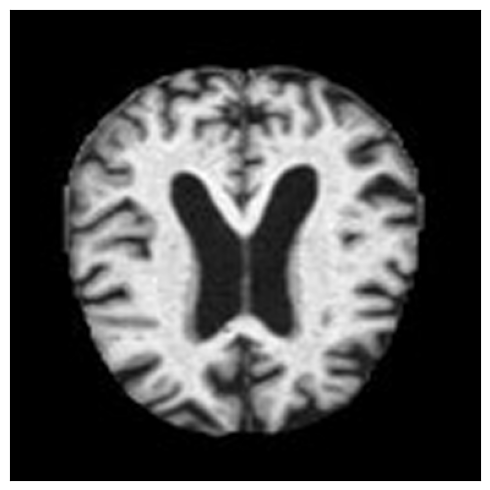

In [35]:
imgs = []

for file_path in [path+'Mild_Demented/mild.jpg']:
    img = cv2.imread(file_path)[..., ::-1]
    img = resize_shortest_edge(img, 384, interpolation='auto')
    img = center_crop(img, (384, 384))
    imgs.append(img)

show_images(imgs, per_row=1, imsize=(5, 5))

In [36]:
import torch

inps = [prepare(img, model.default_cfg['mean'], model.default_cfg['std'])
        for img in imgs]

with torch.no_grad():
    out = torch.softmax(model(inps[0]), -1)[0].numpy()

print(out.argmax())

117


In [37]:
from torchvision.models.feature_extraction import get_graph_node_names
from pprint import pprint

train_nodes, eval_nodes = get_graph_node_names(model)

assert([t == e for t, e in zip(train_nodes, eval_nodes)])

pprint(train_nodes[0:5])

['x', 'conv1.0', 'conv1.1', 'conv1.2', 'conv1.3']


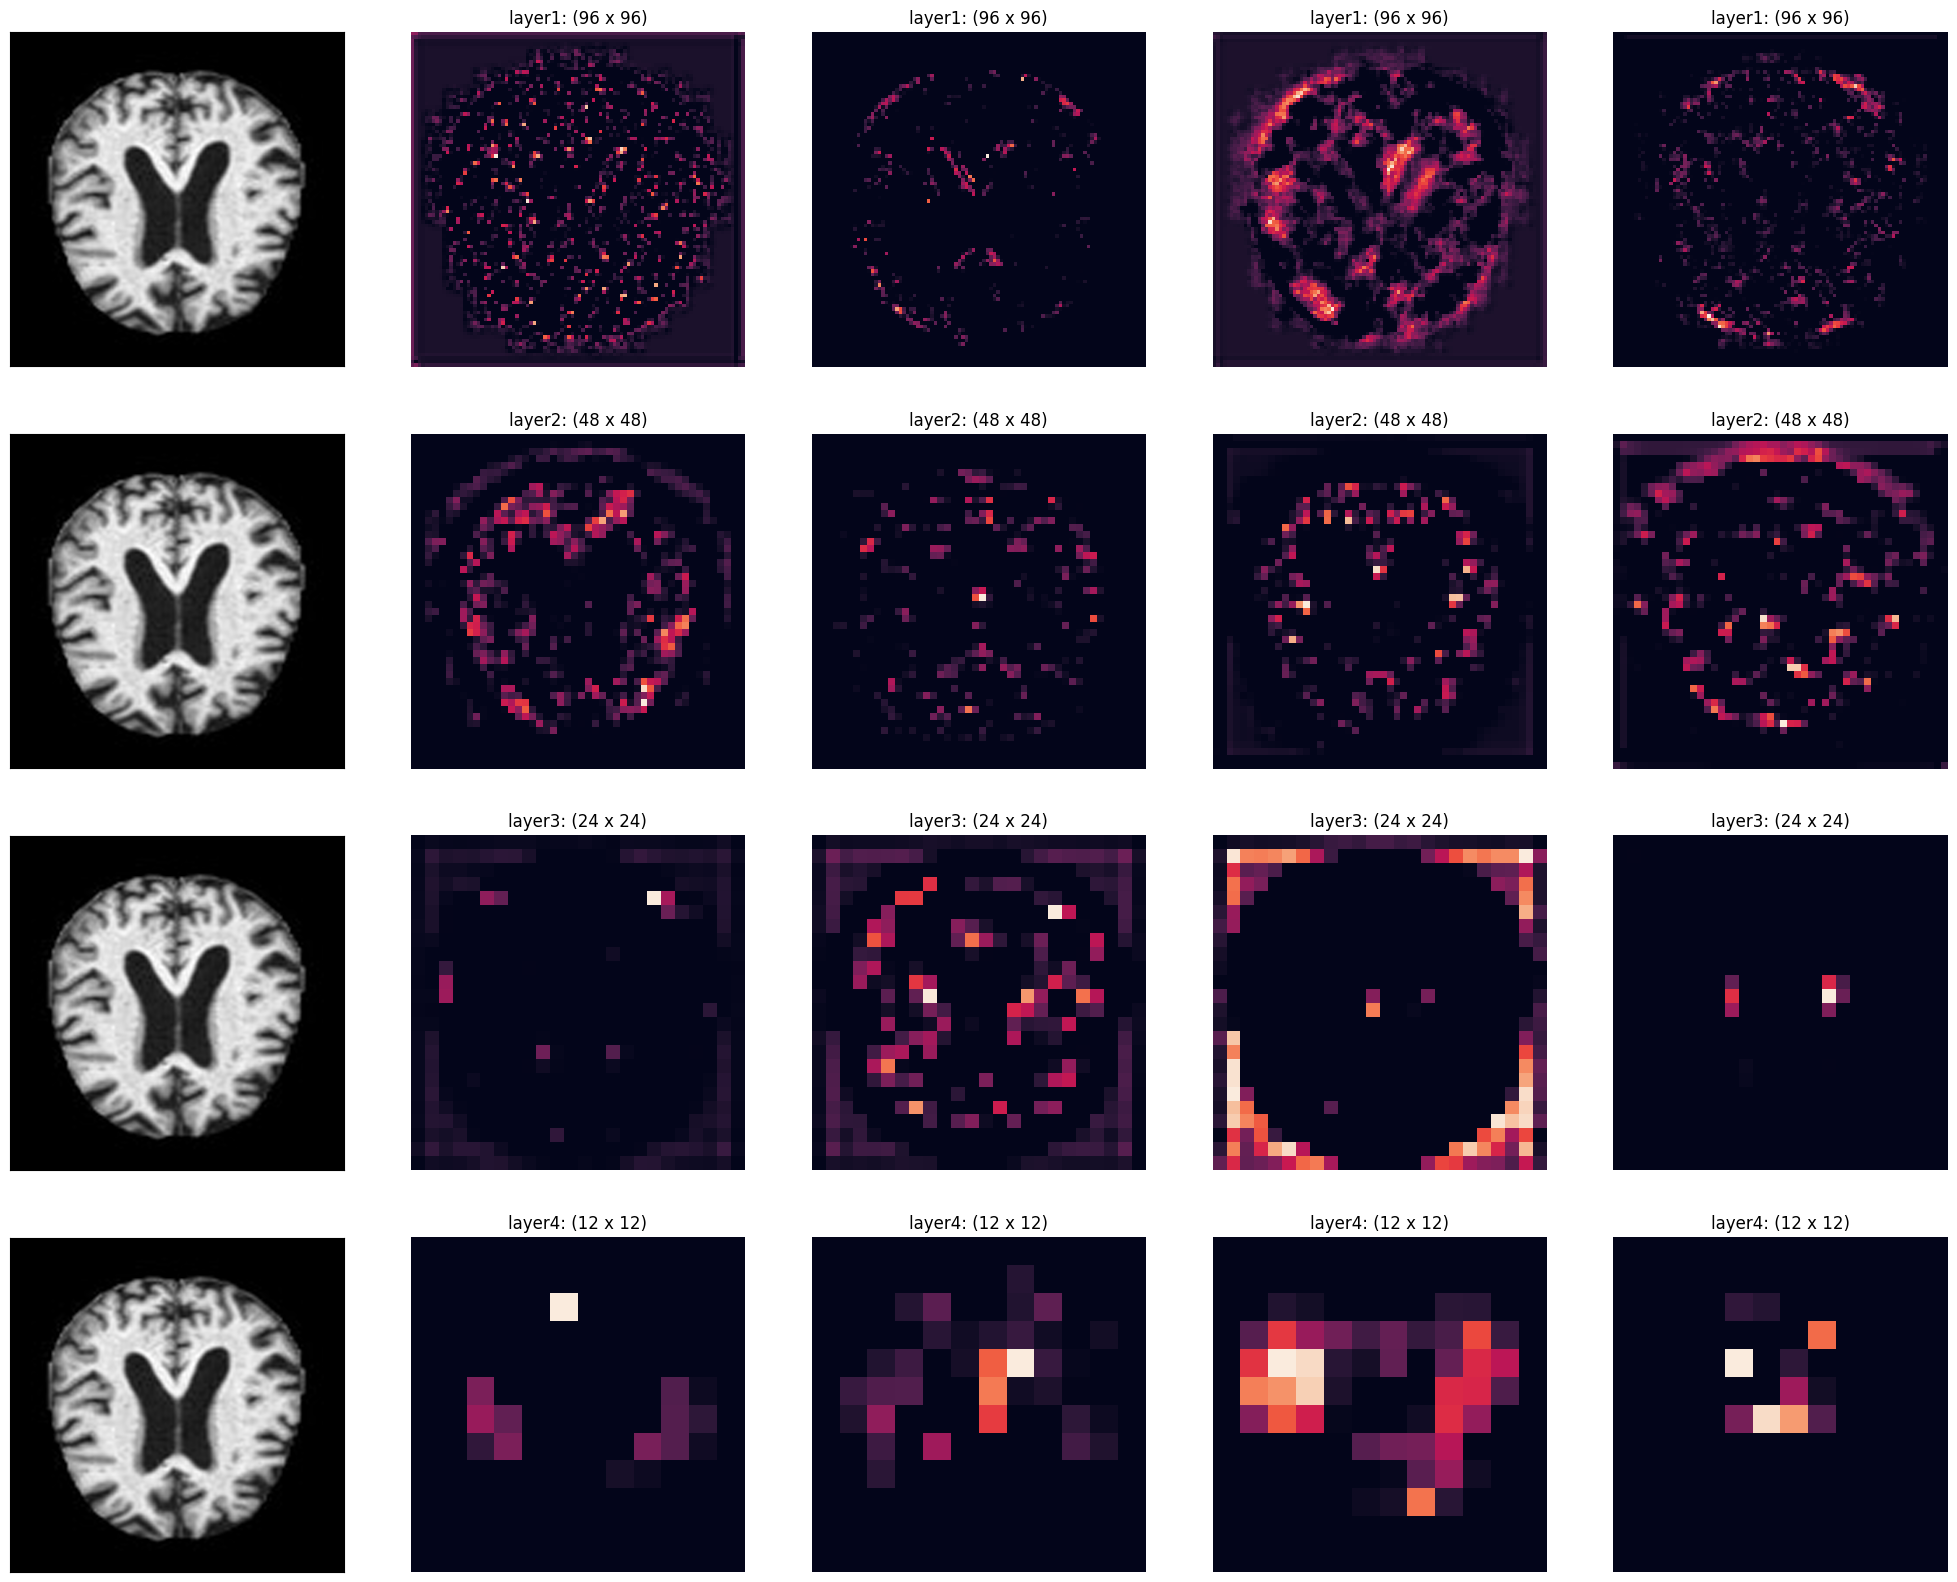

In [38]:
from torchvision.models.feature_extraction import create_feature_extractor
import random
import seaborn as sns
import matplotlib.pyplot as plt

return_nodes = ['layer1', 'layer2', 'layer3', 'layer4']

feat_ext = create_feature_extractor(model, return_nodes=return_nodes)

with torch.no_grad():
    out = feat_ext(inps[0])

fig, ax = plt.subplots(4, 5, figsize=(25, 20))

# Pick 4 random feature maps from each layer
for i, layer in enumerate(return_nodes):
    feat_maps = out[layer].numpy().squeeze(0)
    feat_maps = random.sample(list(feat_maps), 4)
    ax[i][0].imshow(imgs[0])
    ax[i][0].set_xticks([])
    ax[i][0].set_yticks([])
    for j, feat_map in enumerate(feat_maps):
        sns.heatmap(feat_map, ax=ax[i][j+1], cbar=False)
        ax[i][j+1].set_xticks([])
        ax[i][j+1].set_yticks([])
        ax[i][j+1].set_title(f'{layer}: ({feat_map.shape[0]} x {feat_map.shape[1]})')